In [1]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Subh@2002",
    database="hr_employee_db"
)

print("Connected Successfully!")

Connected Successfully!


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pymysql as py
import warnings
warnings.filterwarnings('ignore')
sns.set()


In [3]:
cursor = conn.cursor()


In [4]:
cursor.execute("SHOW DATABASES")

for db in cursor:
    print(db)

('e_commerce_db',)
('financial_db',)
('hr_employee_db',)
('information_schema',)
('mysql',)
('new_schema',)
('performance_schema',)
('pizza',)
('sakila',)
('sys',)


In [5]:
cursor.execute("SHOW TABLES")

for table in cursor:
    print(table)

('hr_employee',)


In [6]:
import pandas as pd

query = "SELECT * FROM hr_employee"
df = pd.read_sql(query, conn)

df.head()

,EmpID,Employee_Name,Sex,MaritalDesc,DeptID,FromDiversityJobFairID,Salary,Position,State,Zip,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,10001,Calvin Candie,M,Single,5,0,72640.0,Production Manager,MA,2169,...,Janet King,2,Indeed,Exceeds,5.0,3,0,2019-02-22,0,14
1,10002,Linda Anderson,F,Single,5,0,57568.0,Production Technician I,MA,1844,...,Amy Dunn,11,LinkedIn,Exceeds,5.0,5,0,2019-01-07,0,15
2,10003,Helen Billis,F,Married,5,0,62910.0,Production Technician I,MA,2031,...,Brannon Miller,12,Indeed,Exceeds,5.0,3,0,2019-02-27,0,19
3,10004,Lindsay Lynch,F,Single,5,1,47434.0,Production Technician I,MA,1844,...,Webster Butler,39,Diversity Job Fair,Exceeds,5.0,4,0,2015-02-02,0,17
4,10005,Lucas Patronick,M,Single,4,1,108987.0,Software Engineer,MA,1844,...,Alex Sweetwater,10,Diversity Job Fair,Exceeds,5.0,5,3,2015-08-16,0,13


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   EmpID                       311 non-null    int64  
 1   Employee_Name               311 non-null    object 
 2   Sex                         311 non-null    object 
 3   MaritalDesc                 311 non-null    object 
 4   DeptID                      311 non-null    int64  
 5   FromDiversityJobFairID      311 non-null    int64  
 6   Salary                      311 non-null    float64
 7   Position                    311 non-null    object 
 8   State                       311 non-null    object 
 9   Zip                         311 non-null    object 
 10  DOB                         311 non-null    object 
 11  CitizenDesc                 311 non-null    object 
 12  HispanicLatino              311 non-null    object 
 13  RaceDesc                    311 non

In [8]:
date_columns = ['DOB', 'DateofHire', 'DateofTermination', 'LastPerformanceReview_Date']
# I changed the date colunms data type to datecolumns
for i in date_columns:
    df[i] = pd.to_datetime(df[i])

# changed the data type of salary column to float from object type
df['Salary'] = df['Salary'].astype('float')

In [9]:
# summary statistics
df.describe(include = 'all')

,EmpID,Employee_Name,Sex,MaritalDesc,DeptID,FromDiversityJobFairID,Salary,Position,State,Zip,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
count,311.000000,311,311,311,311.000000,311.000000,311.000000,311,311,311,...,311,311.000000,311,311,311.000000,311.000000,311.000000,311,311.000000,311.000000
unique,NaN,311,2,5,NaN,NaN,NaN,32,28,158,...,21,NaN,9,4,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Randy Dee,F,Single,NaN,NaN,NaN,Production Technician I,MA,1886,...,Brannon Miller,NaN,Indeed,Fully Meets,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,176,137,NaN,NaN,NaN,137,276,13,...,22,NaN,87,243,NaN,NaN,NaN,NaN,NaN,NaN
mean,10156.000000,NaN,NaN,NaN,4.610932,0.093248,69020.684887,NaN,NaN,NaN,...,NaN,15.199357,NaN,NaN,4.110000,3.890675,1.218650,2017-09-10 21:17:56.527331072,0.414791,10.237942
min,10001.000000,NaN,NaN,NaN,1.000000,0.000000,45046.000000,NaN,NaN,NaN,...,NaN,1.000000,NaN,NaN,1.120000,1.000000,0.000000,2010-07-14 00:00:00,0.000000,1.000000
25%,10078.500000,NaN,NaN,NaN,5.000000,0.000000,55501.500000,NaN,NaN,NaN,...,NaN,10.000000,NaN,NaN,3.690000,3.000000,0.000000,2016-03-19 12:00:00,0.000000,5.000000
50%,10156.000000,NaN,NaN,NaN,5.000000,0.000000,62810.000000,NaN,NaN,NaN,...,NaN,16.000000,NaN,NaN,4.280000,4.000000,0.000000,2019-01-16 00:00:00,0.000000,10.000000
75%,10233.500000,NaN,NaN,NaN,5.000000,0.000000,72036.000000,NaN,NaN,NaN,...,NaN,19.500000,NaN,NaN,4.700000,5.000000,0.000000,2019-02-04 00:00:00,0.000000,15.000000
max,10311.000000,NaN,NaN,NaN,6.000000,1.000000,250000.000000,NaN,NaN,NaN,...,NaN,39.000000,NaN,NaN,5.000000,5.000000,8.000000,2019-02-28 00:00:00,6.000000,20.000000


In [10]:
# Frequency of categorical variables
df.Sex.value_counts()


Sex
F     176
M     135
Name: count, dtype: int64

In [11]:

df.MaritalDesc.value_counts()

MaritalDesc
Single       137
Married      124
Divorced      30
Separated     12
Widowed        8
Name: count, dtype: int64

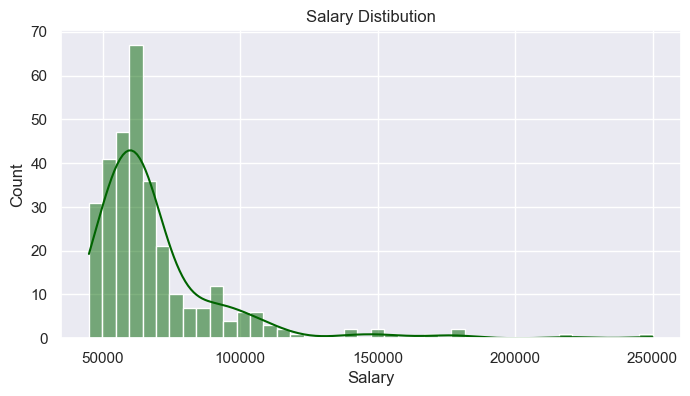

In [13]:
plt.figure(figsize = (8, 4))

sns.histplot(df.Salary, kde=True, color = 'darkgreen')
plt.title('Salary Distibution')
plt.show()

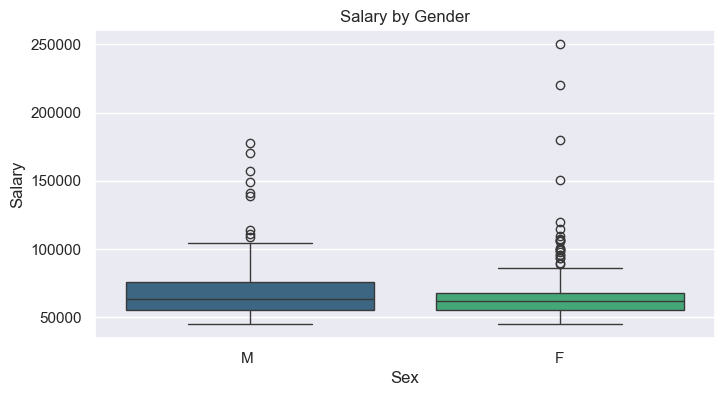

In [22]:
plt.figure(figsize = (8, 4))

sns.boxplot(x = 'Sex', y = 'Salary', data=df, palette='viridis')
plt.title('Salary by Gender')
plt.show()

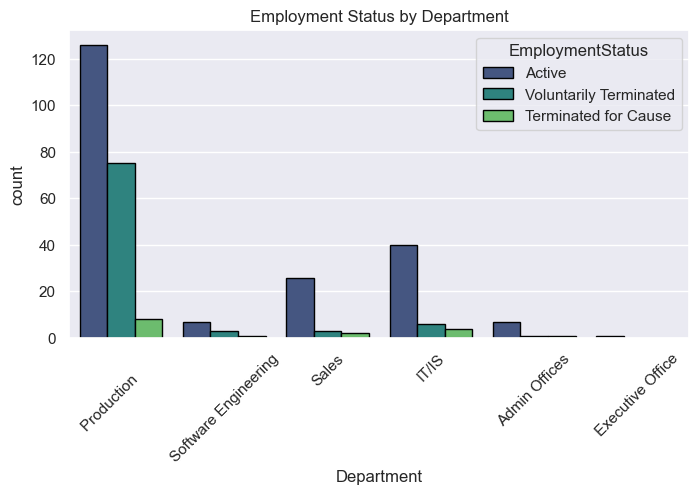

In [24]:
plt.figure(figsize=(8,4))
sns.countplot(x='Department', hue='EmploymentStatus',
              data=df, palette='viridis', edgecolor='black')
plt.title('Employment Status by Department')
plt.xticks(rotation=45)
plt.show()

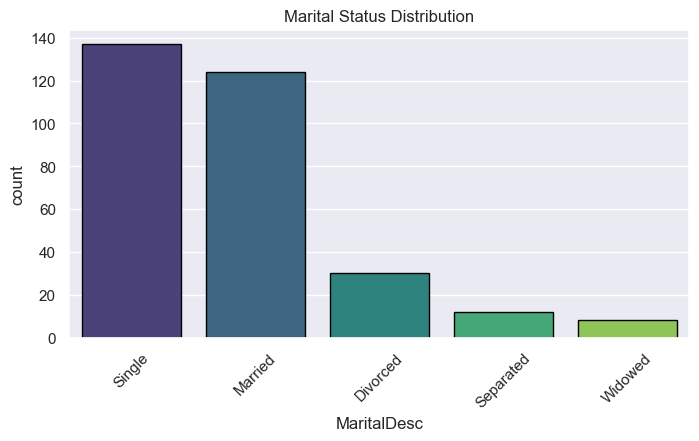

In [25]:
plt.figure(figsize=(8,4))

sns.countplot(x='MaritalDesc', data=df,
              palette='viridis', edgecolor='black')
plt.title('Marital Status Distribution')
plt.xticks(rotation=45)
plt.show()

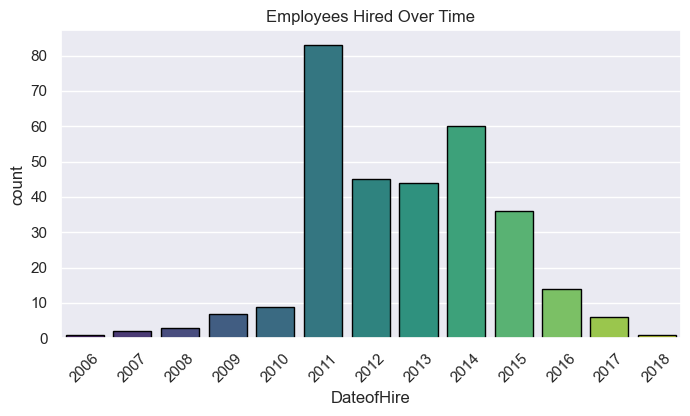

In [26]:
plt.figure(figsize=(8,4))

sns.countplot(x=df['DateofHire'].dt.year,
              palette='viridis',
              edgecolor='black')

plt.title('Employees Hired Over Time')
plt.xticks(rotation=45)
plt.show()

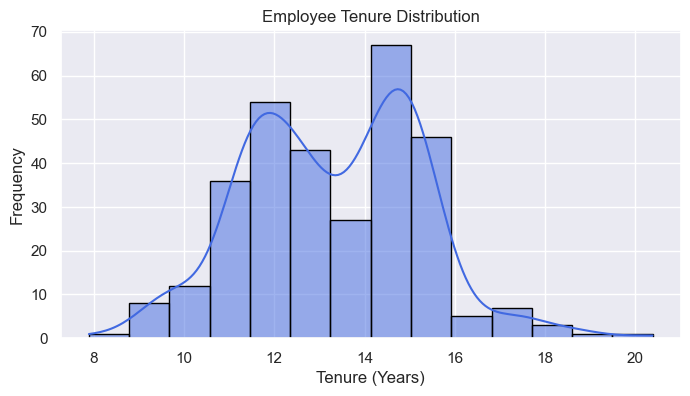

In [27]:
df['Tenure'] = (pd.to_datetime('today') - df['DateofHire']).dt.days / 365.25

plt.figure(figsize=(8,4))
sns.histplot(df['Tenure'],
             color='royalblue',
             kde=True,
             edgecolor='black')

plt.title('Employee Tenure Distribution')
plt.xlabel('Tenure (Years)')
plt.ylabel('Frequency')
plt.show()

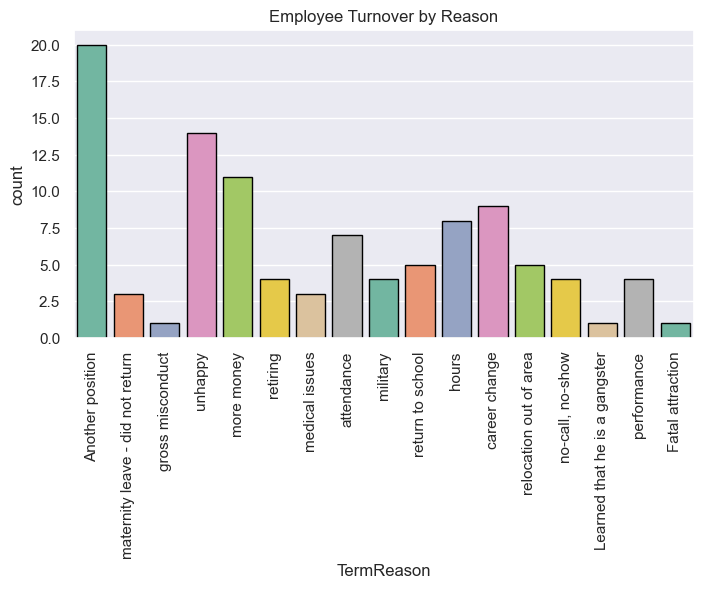

In [29]:
plt.figure(figsize=(8,4))

sns.countplot(x='TermReason',
              data=df[df.TermReason != 'N/A-StillEmployed'],
              palette='Set2',
              edgecolor='black')

plt.title('Employee Turnover by Reason')
plt.xticks(rotation=90)
plt.show()

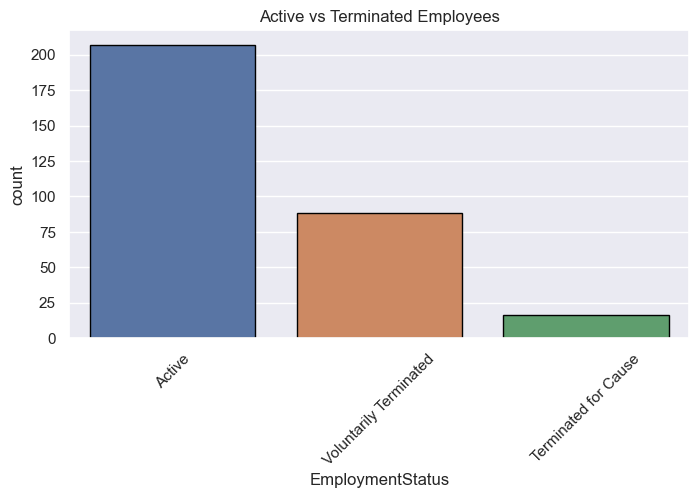

In [30]:
plt.figure(figsize=(8,4))

sns.countplot(x='EmploymentStatus',
              data=df,
              palette='deep',
              edgecolor='black')

plt.title('Active vs Terminated Employees')
plt.xticks(rotation=45)
plt.show()

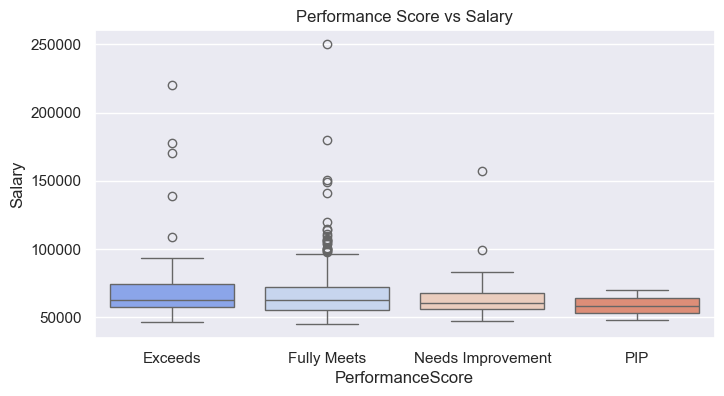

In [31]:
plt.figure(figsize=(8,4))

sns.boxplot(x='PerformanceScore',
            y='Salary',
            data=df,
            palette='coolwarm')

plt.title('Performance Score vs Salary')
plt.show()

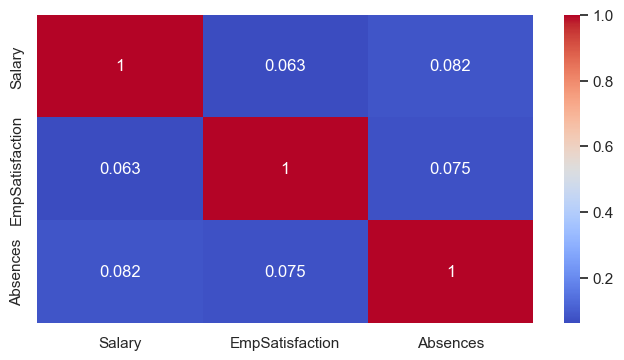

In [32]:
plt.figure(figsize=(8,4))

correlation = df[['Salary', 'EmpSatisfaction', 'Absences']].corr()

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.show()

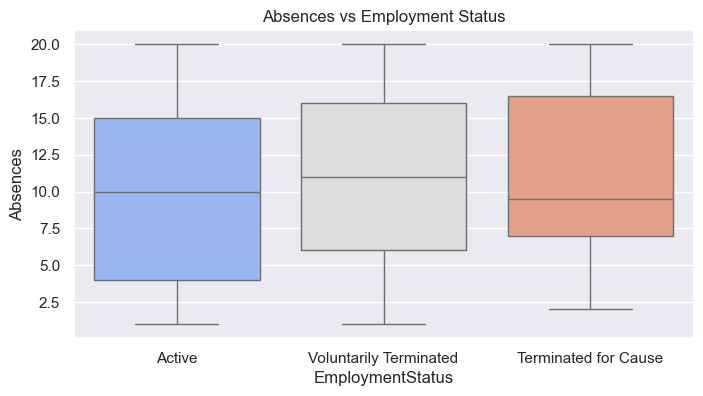

In [33]:
plt.figure(figsize=(8,4))

sns.boxplot(x='EmploymentStatus',
            y='Absences',
            data=df,
            palette='coolwarm')

plt.title('Absences vs Employment Status')
plt.show()

<Figure size 800x500 with 0 Axes>

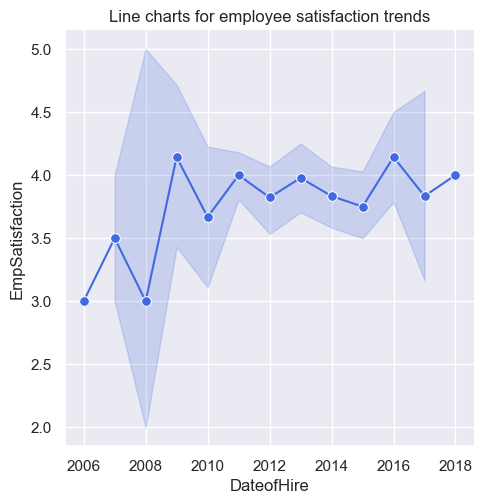

In [34]:
plt.figure(figsize=(8,5))

sns.relplot(x=df['DateofHire'].dt.year,
            y='EmpSatisfaction',
            data=df,
            kind='line',
            marker='o',
            color='royalblue',
            markersize=7)

plt.title('Line charts for employee satisfaction trends')
plt.show()

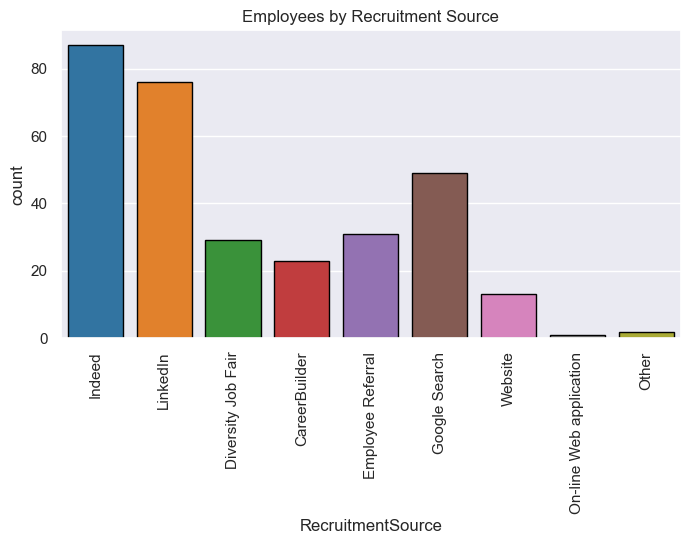

In [36]:
plt.figure(figsize=(8,4))

sns.countplot(x='RecruitmentSource',
              data=df,
              palette='tab10',
              edgecolor='black')

plt.title('Employees by Recruitment Source')
plt.xticks(rotation=90)
plt.show()